In [1]:
import utils_inverse
import utils_plotting
%load_ext autoreload
%autoreload 2

# Use inverse model to find optimal emissions time series for CO<sub>2</sub> using SCM calibrated to MESM

## 1. Generate initial parameters, test backpropagation, and create baseline emulator

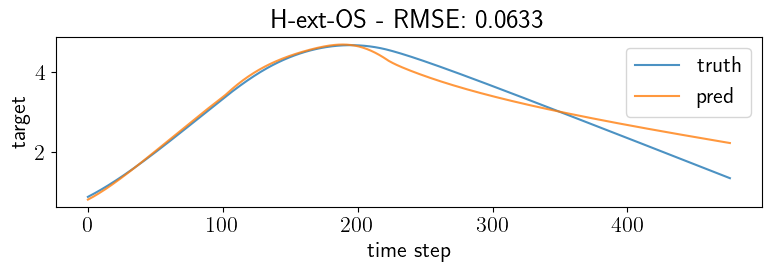

Getting gradient for historical...
	||grad BC||: 0.0
	||grad CH4||: 0.0
	||grad CO2||: 0.00011644609912764281
	||grad N2O||: 0.0
	||grad Sulfur||: 0.0


In [2]:
# Required to generate baseline parameters
agents        = ['CO2']       # Forcing agents included in temperatutre simulations
active_agents = ("CO2",)       # Forcing agents with active gradients (can differ from above)
hidden_sizes  = [16]          # Dimension of neural network emulator
idx_demo      = 1             # Index of scenario to plot
test_scen     = 'historical'  # Scenario to test backpropagation; gradient printed wrt this scenario
verbose       = False         # Flag to print RMSE values for test
mode          = 'MESM'        # Run SCM calibrated to MESM

# Generate initial parameters and test backpropagation
params0, emis_dict_train_JAX = utils_inverse.generate_init_params_and_train_data(agents,
                                                                                 active_agents,
                                                                                 test_scen,
                                                                                 hidden_sizes=hidden_sizes,
                                                                                 idx_demo=idx_demo,
                                                                                 verbose=verbose,
                                                                                 mode=mode)

In [3]:
# Generate data for emulator evaluation
(eval_sets,
emis_dict_tier1_JAX,
emis_dict_tier2_JAX,
emis_dict_DECK_JAX,
emis_dict_CS3_JAX,
emis_dict_all_JAX) = utils_inverse.generate_eval_data(agents, CS3=True, DAMIP=False, GeoMIP=False)

In [4]:
# Baseline emulator parameters
save_path   = None#'checkpoints/co2/baseline_co2_only_MESM.pkl' # Location to save baseline data
verbose     = False # Flag to print NRMSE values from the baseline emulator

# Create baseline emulator
baseline_results, baseline_pred_delT, ground_truth_delT = utils_inverse.generate_and_eval_baseline_emulator(emis_dict_tier1_JAX,
                                                                                                            eval_sets, save_path=save_path,
                                                                                                            verbose=verbose, hidden_sizes=hidden_sizes,
                                                                                                            mode=mode)

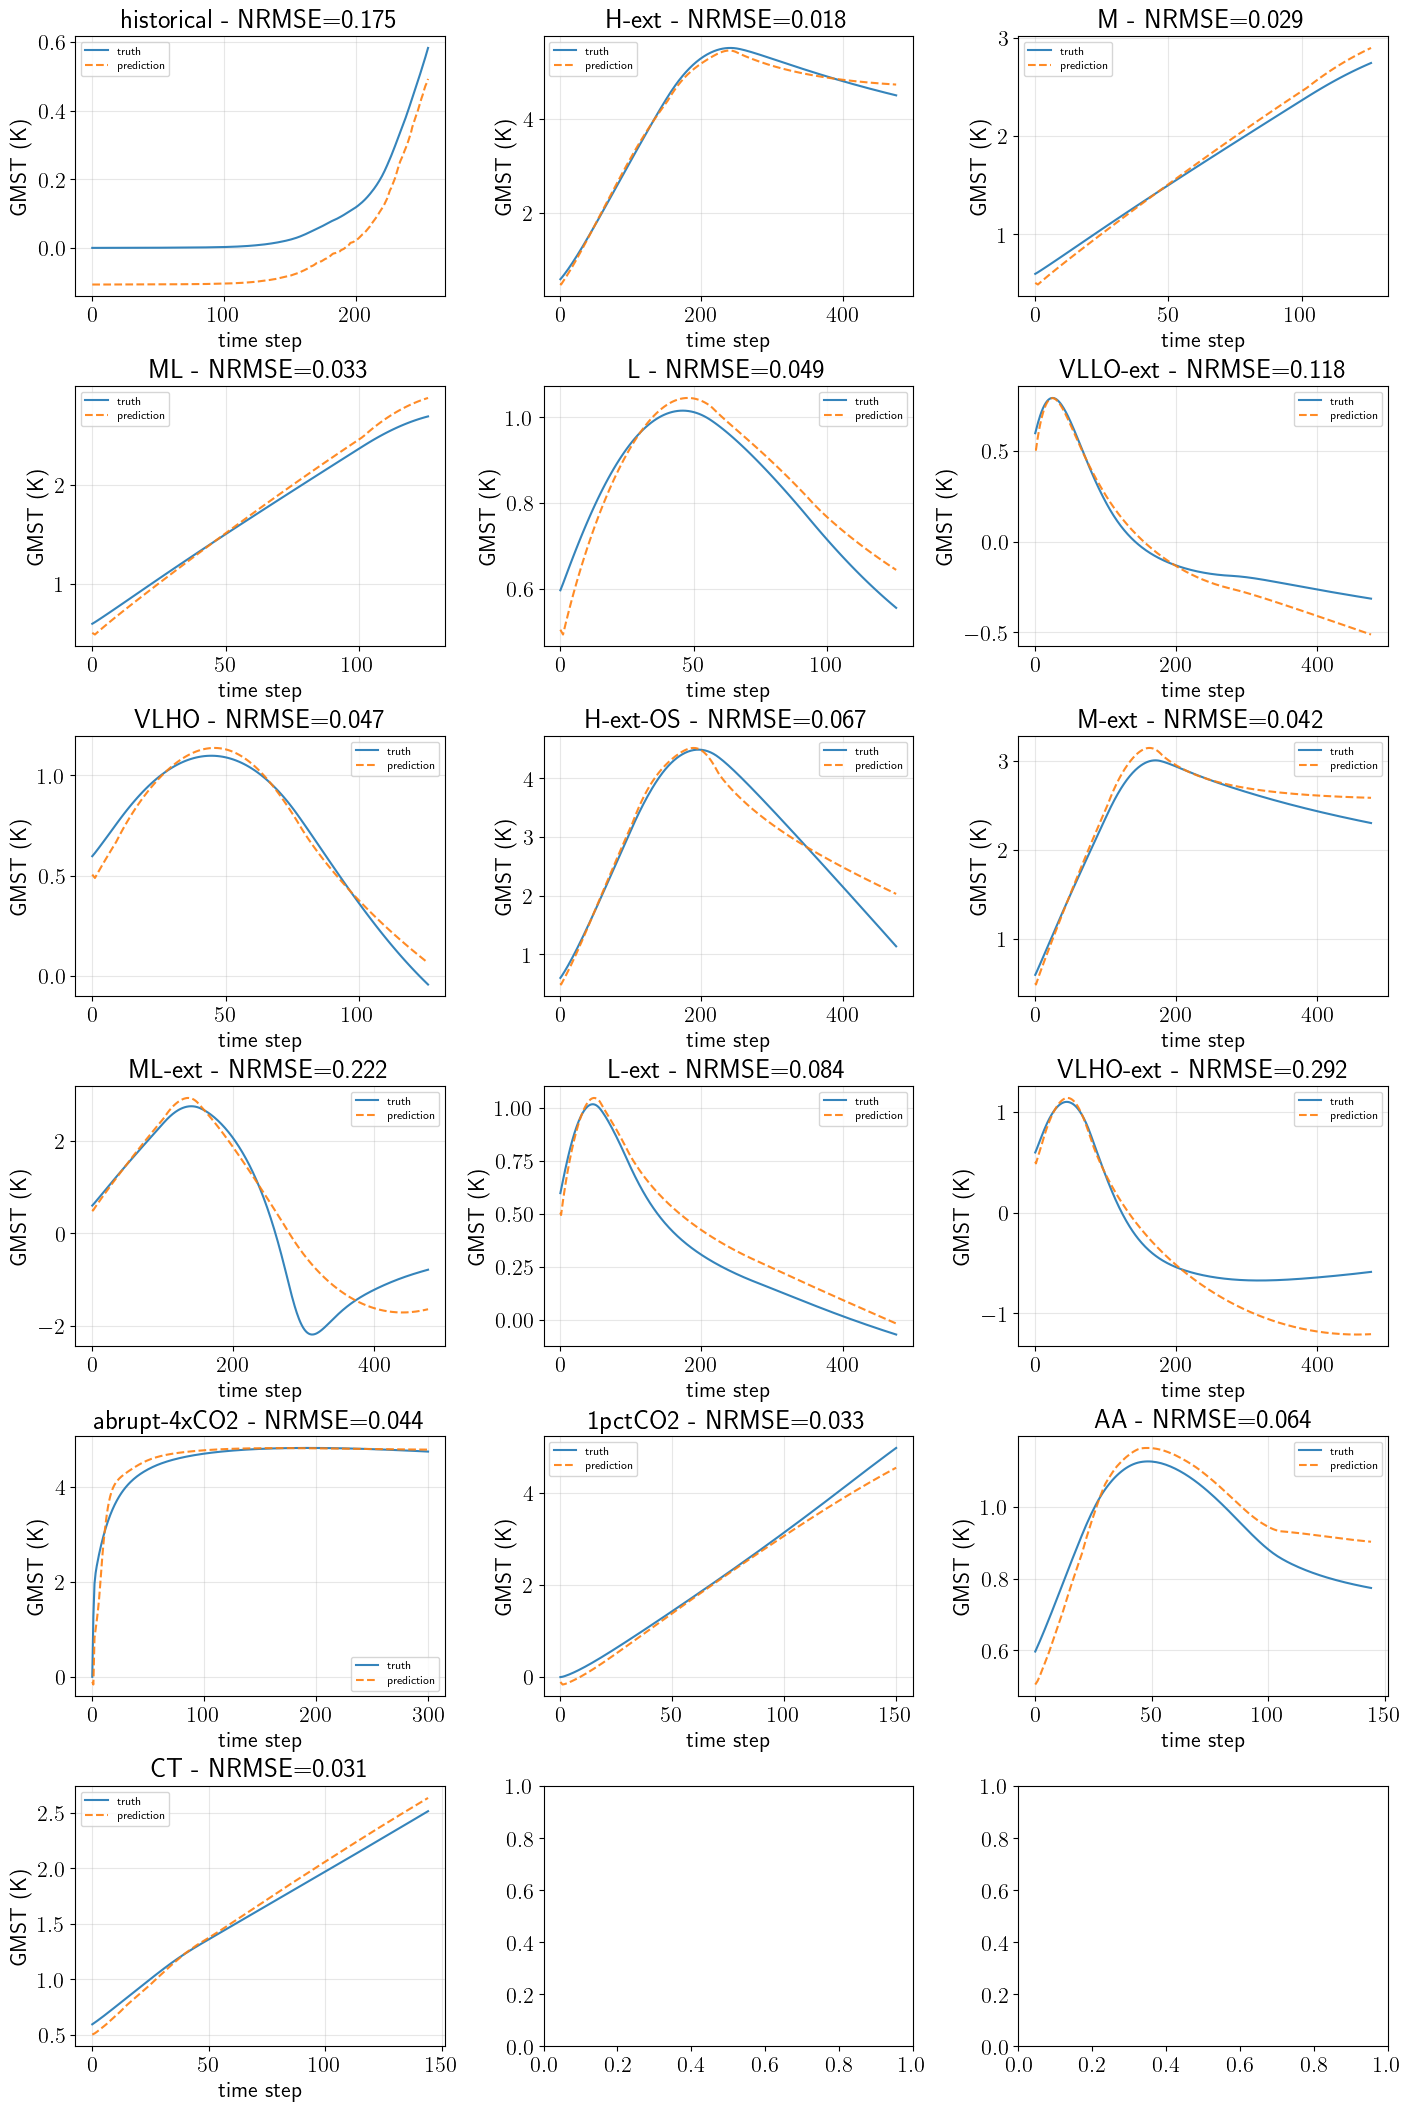

In [5]:
# Optional: plot predictions of baseline emulator
utils_plotting.plot_baseline_pred_delT(baseline_results, baseline_pred_delT, ground_truth_delT)

## 2. Optimize CO<sub>2</sub> emissions time series used in training

### 2a. Optimize for individual scenario (H-ext), starting from constant initial condition

In [ ]:
# Compute migrated to scripts/4a_inverse_CO2_only_MESM.py (run standalone / scheduled) - this cell just loads the resulting checkpoint.
results_CO2_Hext_const = utils_inverse.load_inverse_ckpt('checkpoints/co2/inverse_sine_H-ext_co2_only_MESM.pkl')


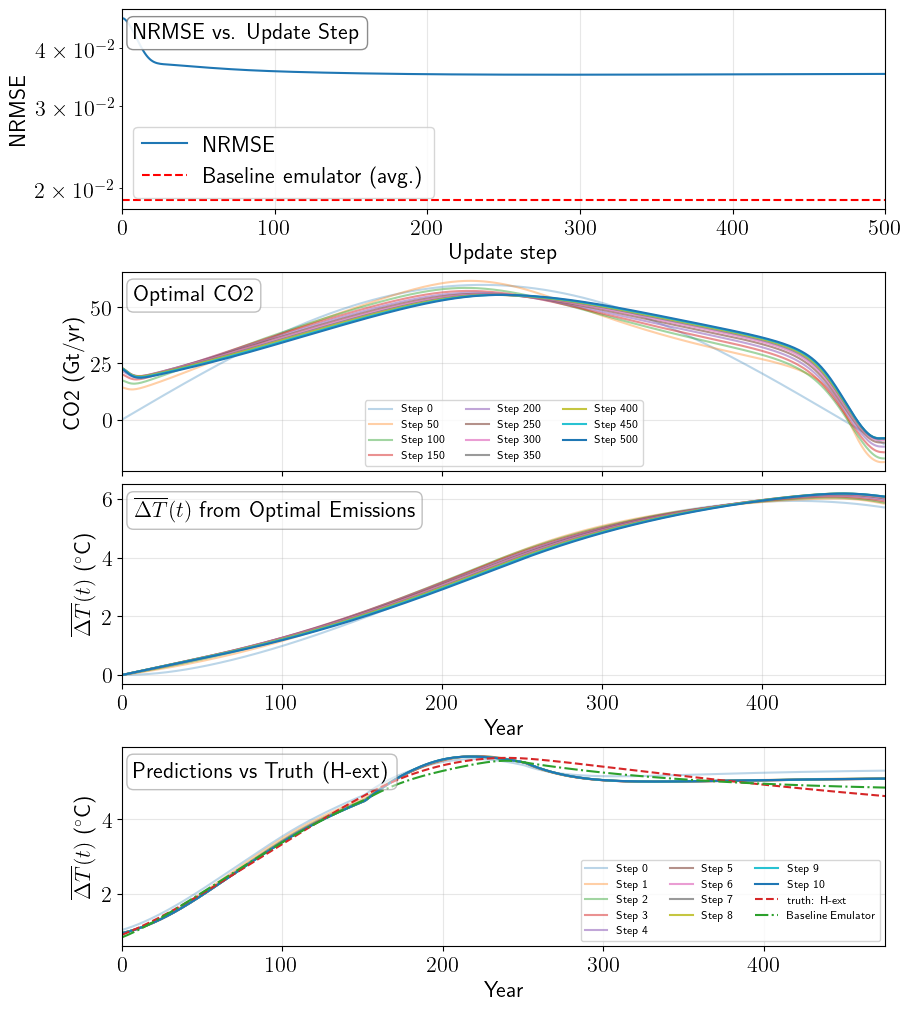

In [18]:
# Optional: plot results of optimization
predict_plot = 'H-ext'

utils_plotting.plot_inverse_results(
    results_CO2_Hext_const,
    baseline_results['Tier 1'][predict_plot],
    active_agents=('CO2',),
    pred_scenario=predict_plot,
    baseline_preds=baseline_pred_delT['Tier 1'][predict_plot]
)

### 2b. Optimize training data for predictive skill over all evaluation sets

In [ ]:
# Compute migrated to scripts/4a_inverse_CO2_only_MESM.py (run standalone / scheduled) - this cell just loads the resulting checkpoints.
results_CO2_dict = {
    'all': utils_inverse.load_inverse_ckpt('checkpoints/co2/inverse_sine_all_co2_only_MESM.pkl'),
    'tier2': utils_inverse.load_inverse_ckpt('checkpoints/co2/inverse_sine_tier2_co2_only_MESM.pkl'),
    'DECK': utils_inverse.load_inverse_ckpt('checkpoints/co2/inverse_sine_DECK_co2_only_MESM.pkl'),
    'CS3': utils_inverse.load_inverse_ckpt('checkpoints/co2/inverse_sine_CS3_co2_only_MESM.pkl')
}


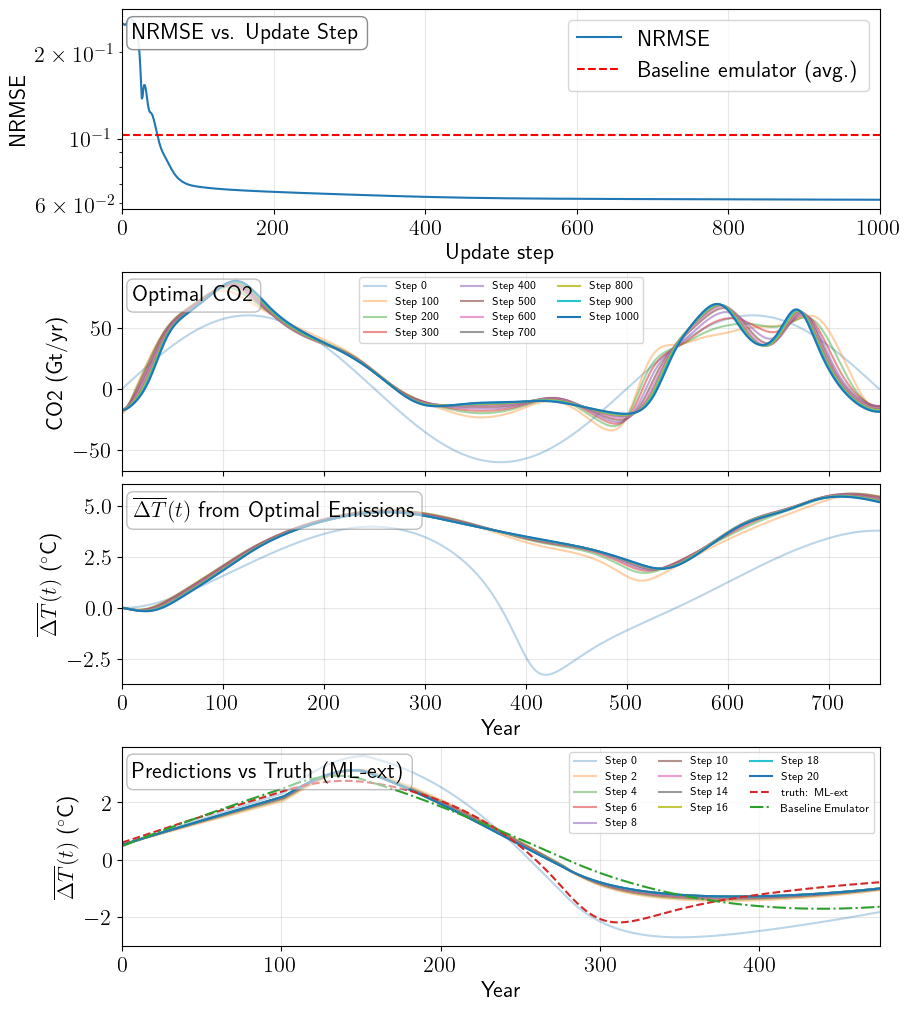

In [42]:
# Optional: plot results of optimization
## Plotting parameters
opt_test        = 'all'  # Evaluation set to plot optimized results for
baseline_test   = 'All' # Evaluation set to plot baseline results for
predict_plot    = 'ML-ext'  # Individual scenario to plot predictions

utils_plotting.plot_inverse_results(
    results_CO2_dict[opt_test],
    baseline_results[baseline_test]['mean'],
    active_agents=('CO2',),
    pred_scenario=predict_plot,
    baseline_preds=baseline_pred_delT[baseline_test][predict_plot]
)